In [162]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nvidia-stock-historical-data/NVDA (1).csv


In [163]:
Nvidia_df = pd.read_csv('/kaggle/input/nvidia-stock-historical-data/NVDA (1).csv')
Nvidia_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-22,0.043750,0.048828,0.038802,0.041016,0.037621,2714688000
1,1999-01-25,0.044271,0.045833,0.041016,0.045313,0.041562,510480000
2,1999-01-26,0.045833,0.046745,0.041146,0.041797,0.038337,343200000
3,1999-01-27,0.041927,0.042969,0.039583,0.041667,0.038218,244368000
4,1999-01-28,0.041667,0.041927,0.041276,0.041536,0.038098,227520000


> # Correlation Analysis

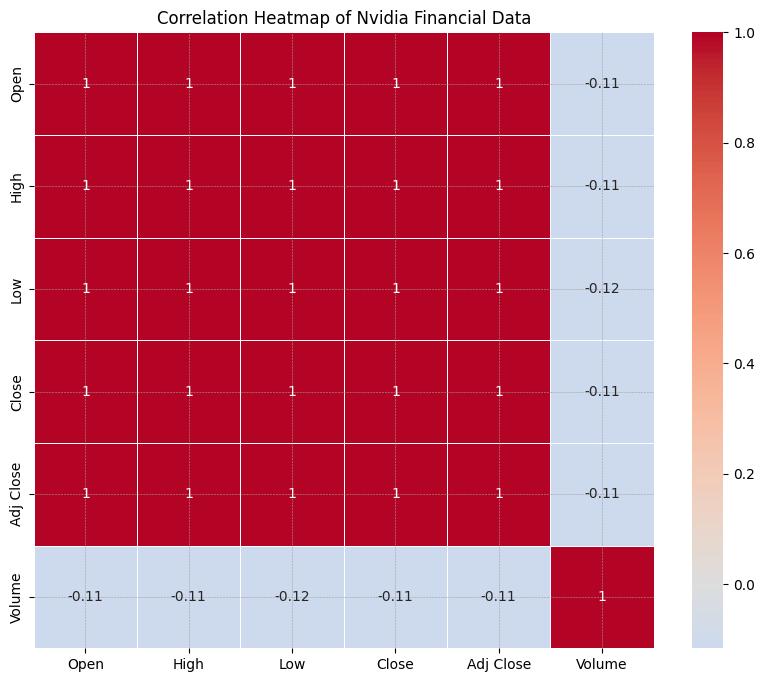

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


correlation_matrix = Nvidia_df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=.5)
plt.title('Correlation Heatmap of Nvidia Financial Data')
plt.show()

# Handling Null Values and Statistics of the Data

In [165]:
Nvidia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6393 entries, 0 to 6392
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6393 non-null   object 
 1   Open       6393 non-null   float64
 2   High       6393 non-null   float64
 3   Low        6393 non-null   float64
 4   Close      6393 non-null   float64
 5   Adj Close  6393 non-null   float64
 6   Volume     6393 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 349.7+ KB


In [166]:
Nvidia_df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-22,0.043750,0.048828,0.038802,0.041016,0.037621,2714688000
1,1999-01-25,0.044271,0.045833,0.041016,0.045313,0.041562,510480000
2,1999-01-26,0.045833,0.046745,0.041146,0.041797,0.038337,343200000
3,1999-01-27,0.041927,0.042969,0.039583,0.041667,0.038218,244368000
4,1999-01-28,0.041667,0.041927,0.041276,0.041536,0.038098,227520000
5,1999-01-29,0.041536,0.041667,0.039583,0.039583,0.036307,244032000
6,1999-02-01,0.039583,0.040625,0.039583,0.040365,0.037024,154704000
7,1999-02-02,0.039583,0.040625,0.036068,0.037240,0.034158,264096000
8,1999-02-03,0.036719,0.038542,0.036458,0.038021,0.034874,75120000
9,1999-02-04,0.038542,0.041146,0.038021,0.040104,0.036784,181920000


In [167]:
Nvidia_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6393.000000,6393.000000,6393.000000,6393.000000,6393.000000,6.393000e+03
mean,5.691514,5.795385,5.583315,5.696717,5.670234,6.073352e+08
std,14.150863,14.406149,13.878611,14.172098,14.174381,4.328103e+08
min,0.034896,0.035547,0.033333,0.034115,0.031291,1.968000e+07
25%,0.276917,0.285500,0.268750,0.275750,0.252925,3.477010e+08
50%,0.455000,0.463000,0.447500,0.455333,0.424676,5.093040e+08
75%,4.125000,4.167750,4.056500,4.118500,4.077091,7.371920e+08
max,132.990005,136.330002,130.690002,135.580002,135.580002,9.230856e+09


In [168]:
Nvidia_df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [169]:
for col in Nvidia_df.select_dtypes(include = ['object']):
    print(f"The unique values of the categorical features : {Nvidia_df[col]}")

The unique values of the categorical features : 0       1999-01-22
1       1999-01-25
2       1999-01-26
3       1999-01-27
4       1999-01-28
           ...    
6388    2024-06-12
6389    2024-06-13
6390    2024-06-14
6391    2024-06-17
6392    2024-06-18
Name: Date, Length: 6393, dtype: object


In [170]:
for col in Nvidia_df.select_dtypes(include = ['int','float']):
    print(f"The unique values of the numerical features : {Nvidia_df[col].unique()}")

The unique values of the numerical features : [4.37500000e-02 4.42710000e-02 4.58330000e-02 ... 1.29960007e+02
 1.32990005e+02 1.31139999e+02]
The unique values of the numerical features : [4.88280000e-02 4.58330000e-02 4.67450000e-02 ... 1.32839996e+02
 1.33729996e+02 1.36330002e+02]
The unique values of the numerical features : [3.88020000e-02 4.10160000e-02 4.11460000e-02 ... 1.28320007e+02
 1.29580002e+02 1.30690002e+02]
The unique values of the numerical features : [4.10160000e-02 4.53130000e-02 4.17970000e-02 ... 1.31880005e+02
 1.30979996e+02 1.35580002e+02]
The unique values of the numerical features : [3.76210000e-02 4.15620000e-02 3.83370000e-02 ... 1.31880005e+02
 1.30979996e+02 1.35580002e+02]
The unique values of the numerical features : [2714688000  510480000  343200000 ...  309320400  288504400  292395300]


#  **Line Plots to look for patterns and trends over time** 

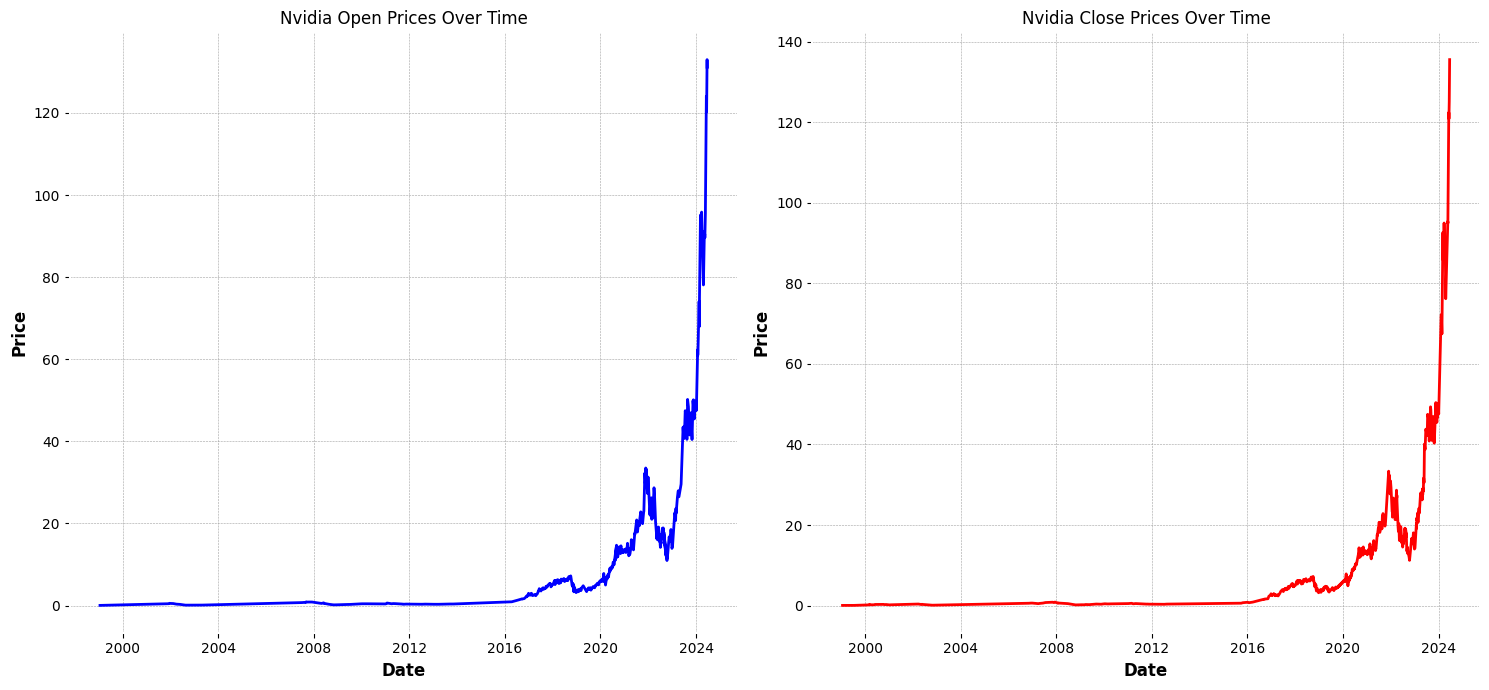

In [171]:

Nvidia_df['Date'] = pd.to_datetime(Nvidia_df['Date'])
Nvidia_df.set_index('Date', inplace=True)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
ax1.plot(Nvidia_df.index, Nvidia_df['Open'], label='Open', color='blue')
ax1.set_title('Nvidia Open Prices Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(True)


ax2.plot(Nvidia_df.index, Nvidia_df['Close'], label='Close', color='red')
ax2.set_title('Nvidia Close Prices Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.grid(True)

plt.tight_layout()
plt.show()


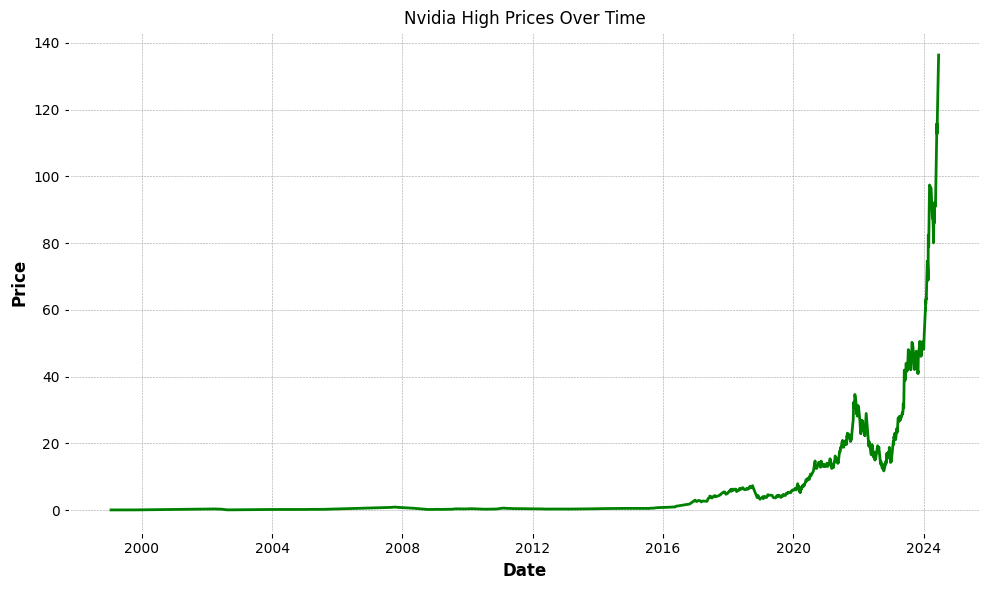

In [172]:
plt.figure(figsize=(10, 6))
plt.plot(Nvidia_df.index, Nvidia_df['High'], label='High', color='green')
plt.title('Nvidia High Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()


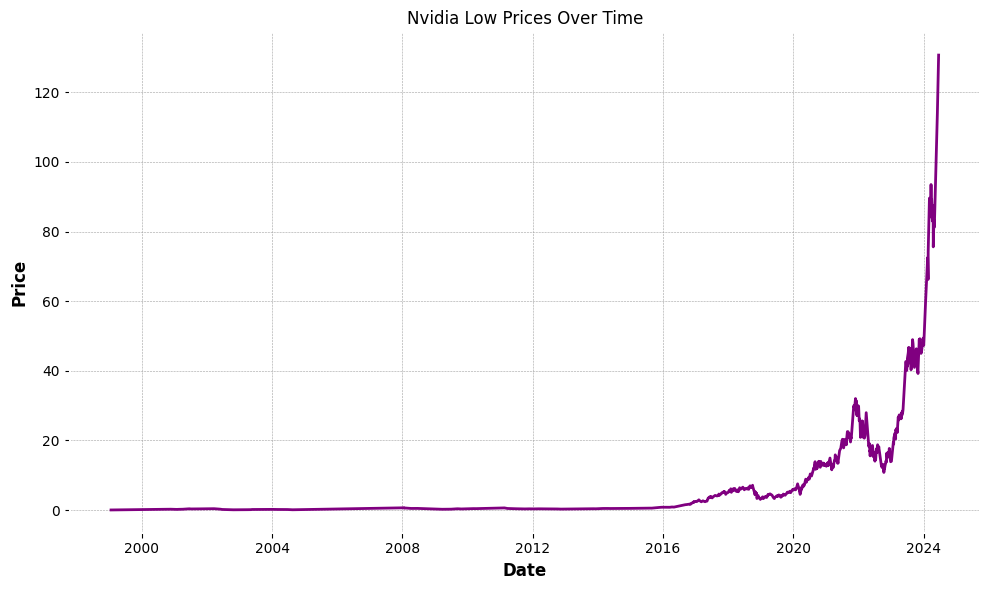

In [173]:
plt.figure(figsize=(10, 6))
plt.plot(Nvidia_df.index, Nvidia_df['Low'], label='Low', color='purple')
plt.title('Nvidia Low Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()


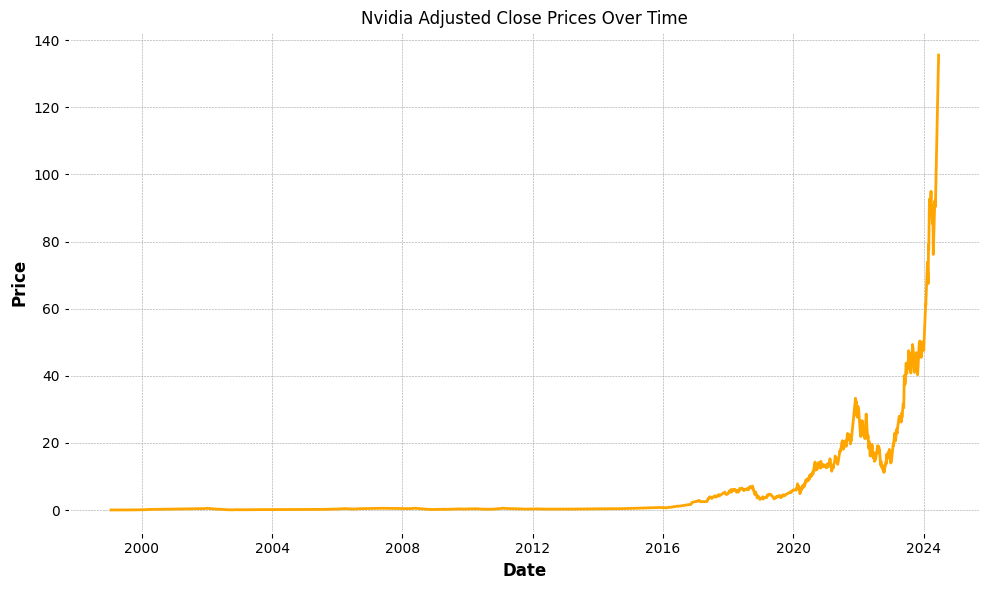

In [174]:
plt.figure(figsize=(10, 6))
plt.plot(Nvidia_df.index, Nvidia_df['Adj Close'], label='Adj Close', color='orange')
plt.title('Nvidia Adjusted Close Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()


# **Volume Analysis(Quantity of shares of Nvidia purchased over time)**

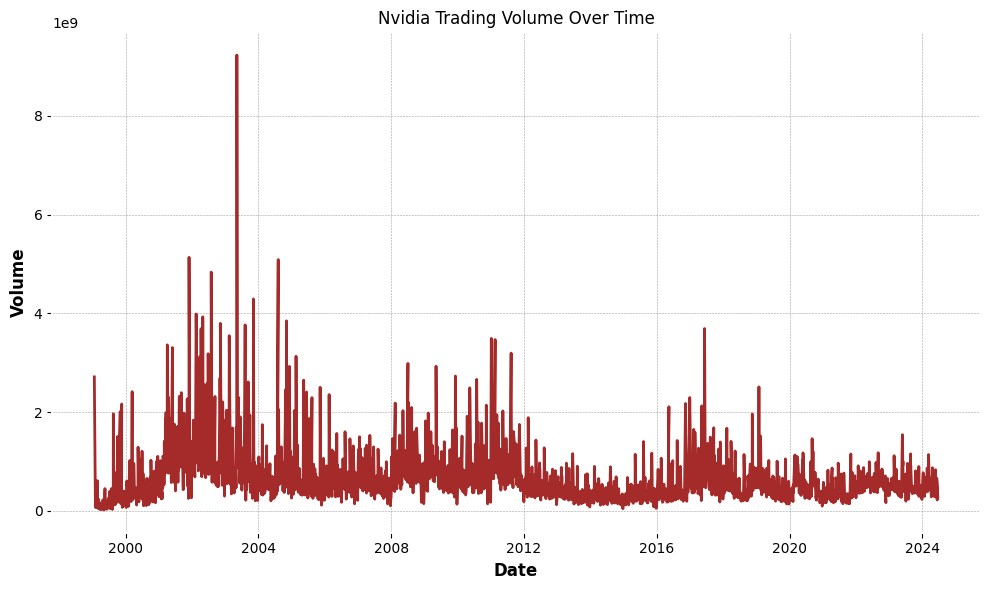

In [175]:
plt.figure(figsize=(10, 6))
plt.plot(Nvidia_df.index, Nvidia_df['Volume'], label='Volume', color='brown')
plt.title('Nvidia Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.tight_layout()
plt.show()


> # **Time Resampling Plots**

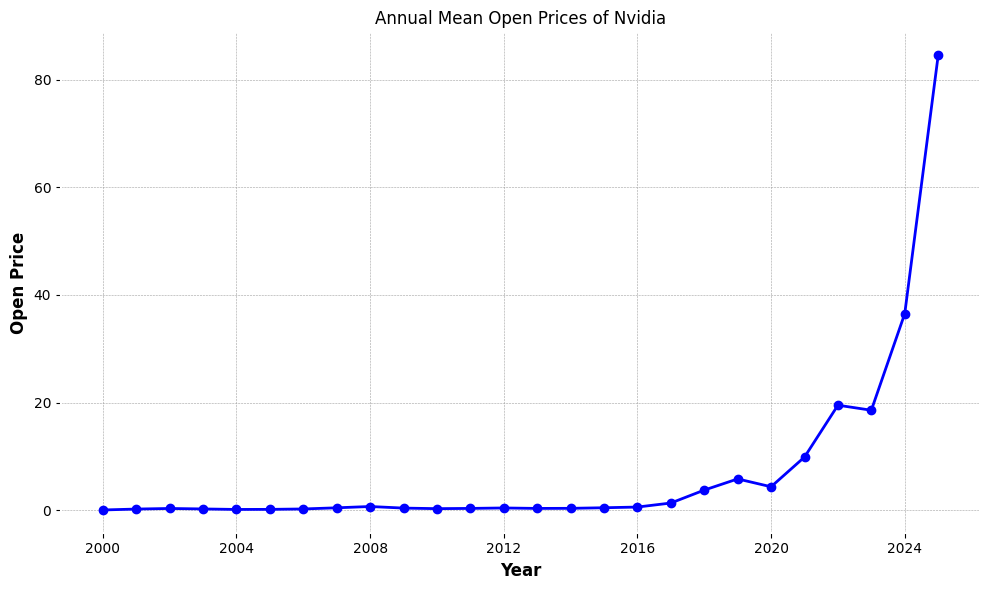

In [176]:

resampled_data = Nvidia_df['Open'].resample('YE').mean()

plt.figure(figsize=(10, 6))
plt.plot(resampled_data.index, resampled_data.values, marker='o', linestyle='-', color='b')
plt.title("Annual Mean Open Prices of Nvidia")
plt.xlabel("Year")
plt.ylabel("Open Price")
plt.grid(True)
plt.tight_layout()
plt.show()


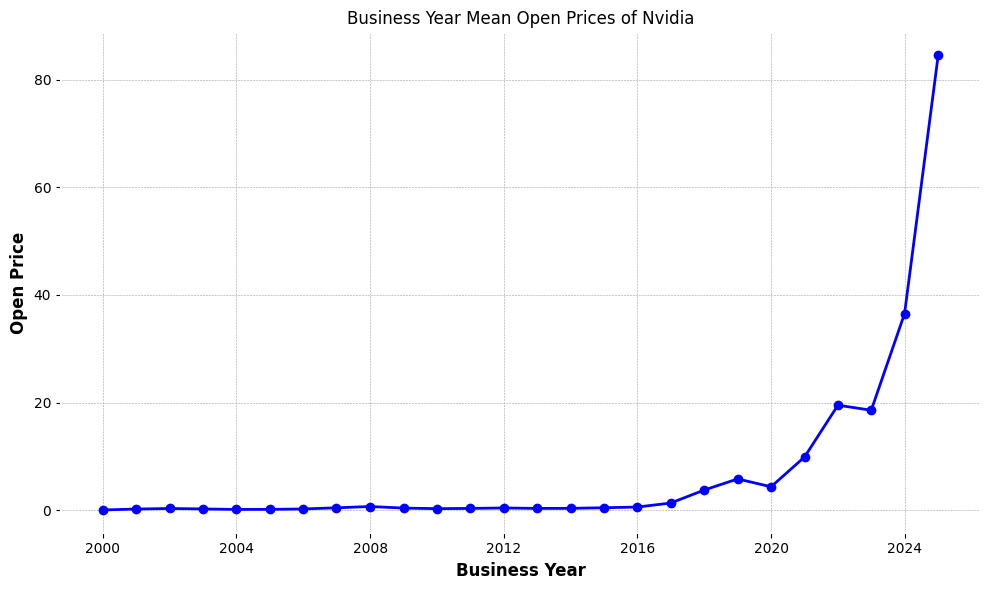

In [177]:
resampled_data_business_year = Nvidia_df['Open'].resample('BYE').mean()

plt.figure(figsize=(10, 6))
plt.plot(resampled_data_business_year.index, resampled_data_business_year.values, marker='o', linestyle='-', color='blue')
plt.title("Business Year Mean Open Prices of Nvidia")
plt.xlabel("Business Year")
plt.ylabel("Open Price")
plt.grid(True)
plt.tight_layout()
plt.show()


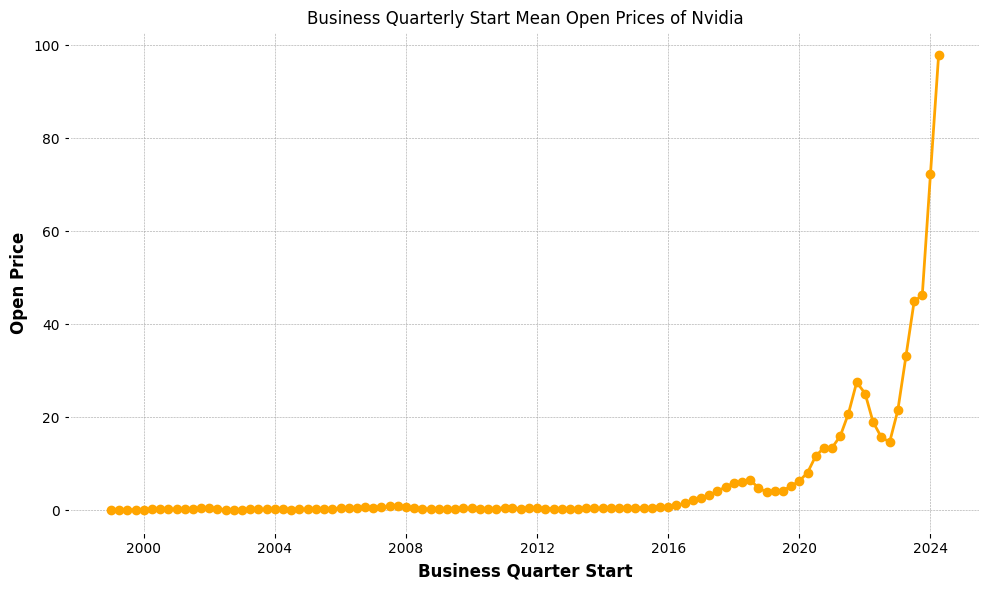

In [178]:
resampled_data_business_quarterly_start = Nvidia_df['Open'].resample('BQS').mean()

plt.figure(figsize=(10, 6))
plt.plot(resampled_data_business_quarterly_start.index, resampled_data_business_quarterly_start.values, marker='o', linestyle='-', color='orange')
plt.title("Business Quarterly Start Mean Open Prices of Nvidia")
plt.xlabel("Business Quarter Start")
plt.ylabel("Open Price")
plt.grid(True)
plt.tight_layout()
plt.show()


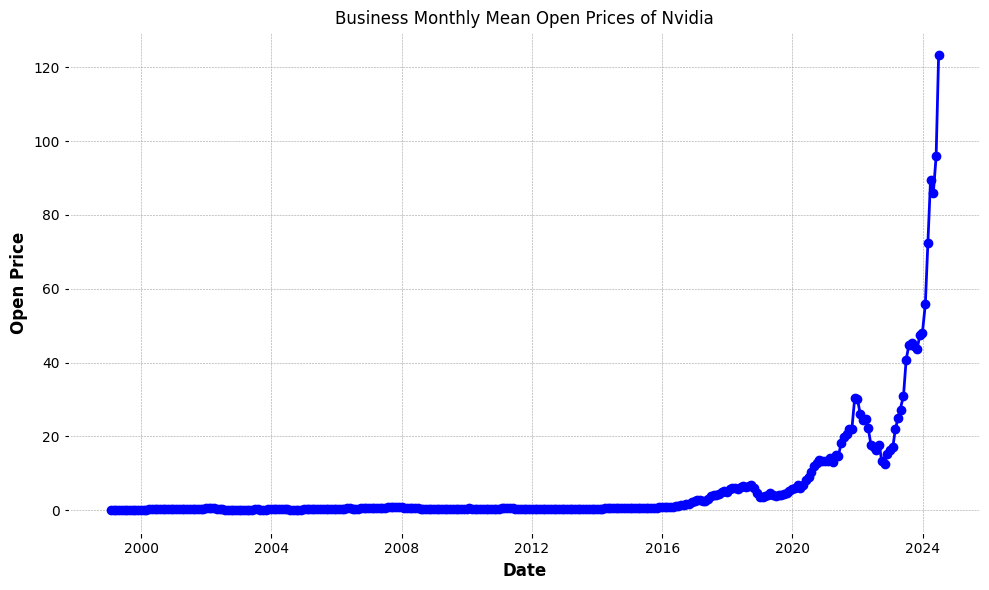

In [179]:
resampled_data_business_month = Nvidia_df['Open'].resample('BME').mean()

plt.figure(figsize=(10, 6))
plt.plot(resampled_data_business_month.index, resampled_data_business_month.values, marker='o', linestyle='-', color='b')
plt.title("Business Monthly Mean Open Prices of Nvidia")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# Rolling

In [180]:
Nvidia_df.reset_index()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-22,0.043750,0.048828,0.038802,0.041016,0.037621,2714688000
1,1999-01-25,0.044271,0.045833,0.041016,0.045313,0.041562,510480000
2,1999-01-26,0.045833,0.046745,0.041146,0.041797,0.038337,343200000
3,1999-01-27,0.041927,0.042969,0.039583,0.041667,0.038218,244368000
4,1999-01-28,0.041667,0.041927,0.041276,0.041536,0.038098,227520000
...,...,...,...,...,...,...,...
6388,2024-06-12,123.059998,126.879997,122.570000,125.199997,125.199997,299595000
6389,2024-06-13,129.389999,129.800003,127.160004,129.610001,129.610001,260704500
6390,2024-06-14,129.960007,132.839996,128.320007,131.880005,131.880005,309320400
6391,2024-06-17,132.990005,133.729996,129.580002,130.979996,130.979996,288504400


<Figure size 1400x700 with 0 Axes>

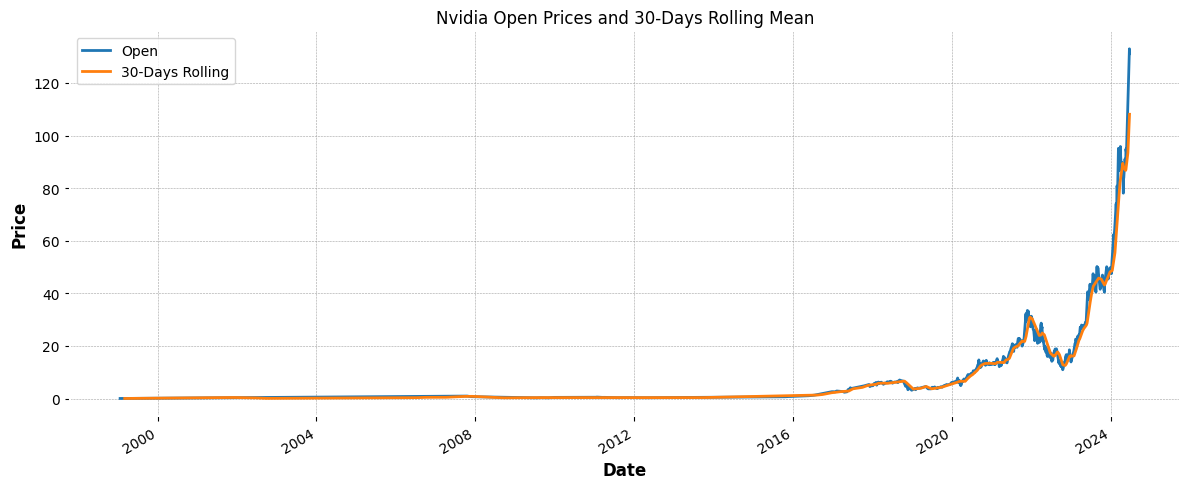

In [181]:
Nvidia_df['30-Days Rolling'] = Nvidia_df['Open'].rolling(window=30).mean()

plt.figure(figsize=(14, 7))
Nvidia_df[['Open', '30-Days Rolling']].plot(figsize=(12, 5))
plt.title("Nvidia Open Prices and 30-Days Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

> # **Nvidia's Time Series Forecasting using an LSTM**

2024-07-03 12:47:57.141550: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-03 12:47:57.141731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-03 12:47:57.292328: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4.6474e-05 - val_loss: 8.7162e-04
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4486e-06 - val_loss: 8.3329e-04
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.5499e-06 - val_loss: 3.8629e-04
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2575e-06 - val_loss: 5.7542e-04
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.7381e-06 - val_loss: 6.1799e-04
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3190e-06 - val_loss: 9.7234e-04
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9815e-06 - val_loss: 4.4061e-04
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.6202e-06 - val_loss: 6.4547e-04
Epoch 9/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5391e-06 - val_loss: 6.6936e-04
Epoch 10/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.0117e-06 - val_loss: 6.4530e-04
Epoch 11/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss

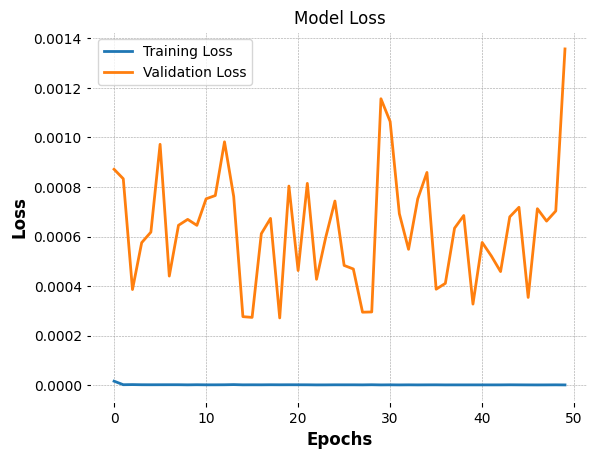

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


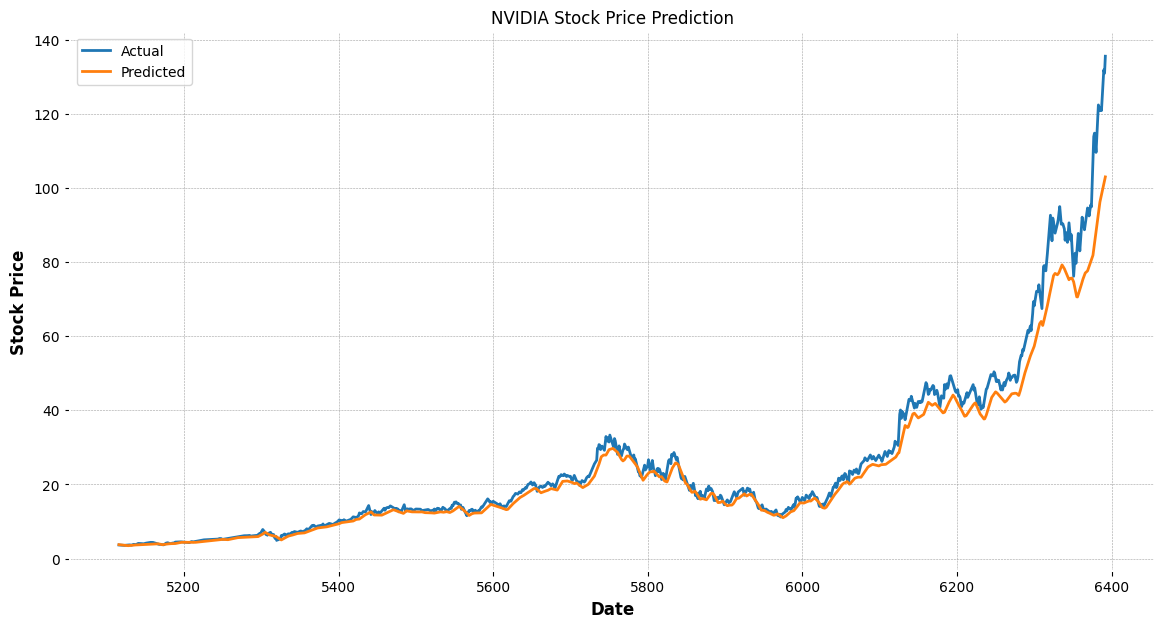

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load data
df = pd.read_csv('/kaggle/input/nvidia-stock-historical-data/NVDA (1).csv')


data = df['Adj Close'].values.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


seq_length = 10  
X, y = create_sequences(scaled_data, seq_length)

train_size = int(len(X) * 0.8) 
test_size = len(X) - train_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)

plt.figure(figsize=(14, 7))
plt.plot(df.index[train_size + seq_length:], df['Adj Close'].values[train_size + seq_length:], label='Actual')
plt.plot(df.index[train_size + seq_length:], predicted_prices, label='Predicted')
plt.title('NVIDIA Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [183]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predictions
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 4.993718563143584
MAE: 2.610088108617533


> # > **Volatility Analysis**

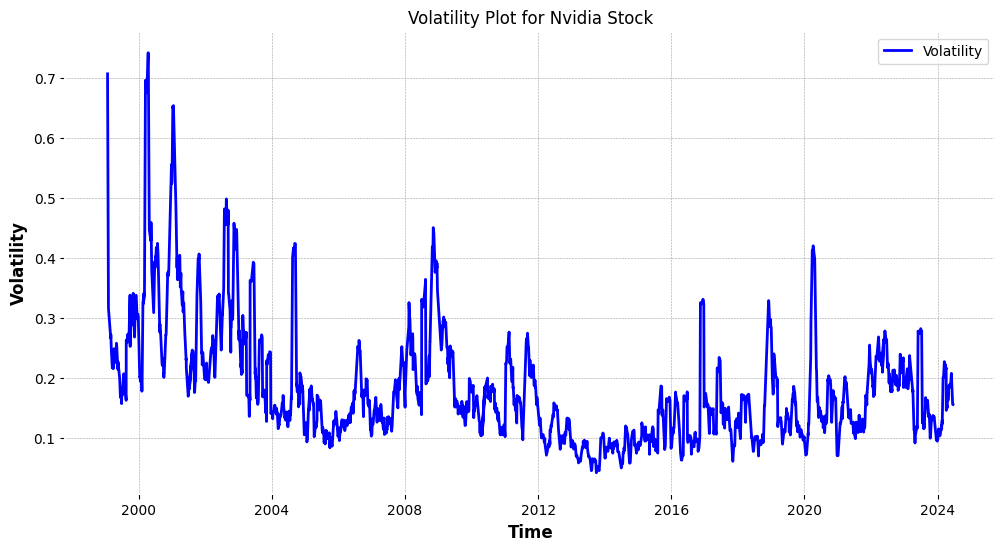

In [195]:

Nvidia_df['Daily_Return'] = Nvidia_df['Close'].pct_change()

window = 30 
Nvidia_df['Volatility'] = Nvidia_df['Daily_Return'].rolling(window, min_periods=1).std() * np.sqrt(window)

# Plot volatility
plt.figure(figsize=(12, 6))
plt.plot(Nvidia_df.index, Nvidia_df['Volatility'], label='Volatility', color='blue')
plt.title('Volatility Plot for Nvidia Stock')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()
